In [649]:
import osmnx as ox
place_name = 'Snohomish, Washington, USA' # Change this to switch cities
G = ox.graph_from_place(place_name, network_type='drive')
# Ensure the graph is strongly connected (guarantees a return path exists)
#G = ox.utils_graph.get_largest_component(G, strongly=True)



In [738]:
start_node = list(G.nodes)[125]  # Arbitrary starting node
end_node = list(G.neighbors(start_node))[0]

In [739]:
type(G)

networkx.classes.multidigraph.MultiDiGraph

In [740]:
len(G.nodes)

30917

In [741]:
len(G.edges)

71455

In [742]:
list(G.edges(data=True))[0]

(30139417,
 2304044269,
 {'osmid': 314941994,
  'highway': 'tertiary',
  'maxspeed': 1693775109.2103658,
  'name': '240th Street Southeast',
  'oneway': False,
  'reversed': False,
  'length': 103.79061701550403,
  'geometry': <LINESTRING (-122.18 47.78, -122.18 47.78, -122.179 47.78, -122.179 47.78)>,
  'grade': 0.17342608144733543,
  'grade_abs': 0.9919286680330861,
  'curvature': 0.0003921437934321484,
  'highway_effectiveness': 0.95})

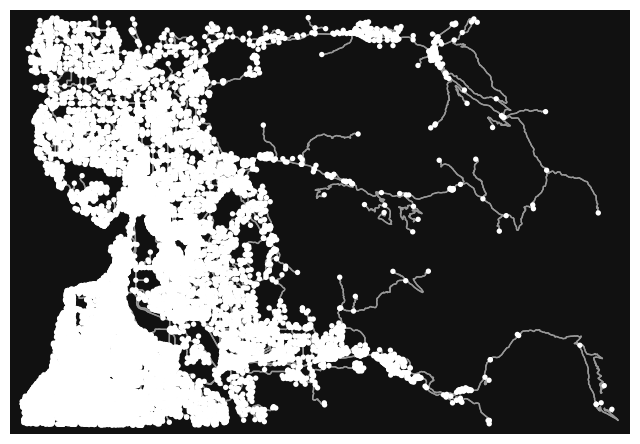

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [743]:
ox.plot_graph(G)


In [744]:
list(G.nodes(data=True))[0]

(30139417,
 {'y': 47.7800028,
  'x': -122.180471,
  'highway': 'stop',
  'street_count': 3,
  'elevation': 26.0})

In [ ]:
ox.settings.elevation_url_template = (
    "https://api.opentopodata.org/v1/aster30m?locations={locations}"
)
G = ox.elevation.add_node_elevations_google(G, batch_size=100, pause=1)
G = ox.elevation.add_edge_grades(G)
print(list(G.nodes(data=True))[0])
print(list(G.edges(data=True))[0])

In [ ]:
gdf_nodes, gdf_edges = ox.convert.graph_to_gdfs(G)
print(gdf_nodes.shape)
print(gdf_edges.shape)
gdf_edges.head()

(30917, 9)
(71455, 20)


osmid      highway  maxspeed  \
u          v          key                                                  
30139417   2304044269 0                 314941994     tertiary  0.437754   
           1194807327 0    [428033729, 428033727]    secondary  0.503268   
           136904439  0                 933078655     tertiary  0.437754   
2304044269 2304044903 0                 314941994     tertiary  0.437754   
           1194807334 0                 221378242  residential  0.365716   

                                             name  oneway reversed  \
u          v          key                                            
30139417   2304044269 0    240th Street Southeast   False    False   
           1194807327 0     39th Avenue Southeast   False     True   
           136904439  0    240th Street Southeast   False     True   
2304044269 2304044903 0    240th Street Southeast   False    False   
           1194807334 0     40th Avenue Southeast   False    False   

                               length  \
u          v          key               
30139417   2304044269 0    103.790617   
           1194807327 0     81.877399   
           136904439  0    404.590873   
2304044269 2304044903 0     40.111093   
           1194807334 0     81.825076   

                                                                    geometry  \
u          v          key                                                      
30139417   2304044269 0    LINESTRING (-122.18047 47.78, -122.18041 47.78...   
           1194807327 0    LINESTRING (-122.18047 47.78, -122.18047 47.77...   
           136904439  0    LINESTRING (-122.18047 47.78, -122.18101 47.78...   
2304044269 2304044903 0    LINESTRING (-122.17908 47.77999, -122.17855 47...   
           1194807334 0    LINESTRING (-122.17908 47.77999, -122.17908 47...   

                              grade  grade_abs  curvature  \
u          v          key                                   
30139417   2304044269 0    0.173426   0.173426   0.000392   
           1194807327 0    0.048854   0.048854   0.000057   
           136904439  0   -0.029660   0.029660   0.000525   
2304044269 2304044903 0    0.149585   0.149585   0.000000   
           1194807334 0    0.061106   0.061106   0.000168   

                           highway_effectiveness   lanes bridge  ref tunnel  \
u          v          key                                                     
30139417   2304044269 0                     0.95     NaN    NaN  NaN    NaN   
           1194807327 0                     0.90  [4, 5]    NaN  NaN    NaN   
           136904439  0                     0.95     NaN    NaN  NaN    NaN   
2304044269 2304044903 0                     0.95     NaN    NaN  NaN    NaN   
           1194807334 0                     0.40     NaN    NaN  NaN    NaN   

                          junction access width area  
u          v          key                             
30139417   2304044269 0        NaN    NaN   NaN  NaN  
           1194807327 0        NaN    NaN   NaN  NaN  
           136904439  0        NaN    NaN   NaN  NaN  
2304044269 2304044903 0        NaN    NaN   NaN  NaN  
           1194807334 0        NaN    NaN   NaN  NaN

In [ ]:
gdf_edges.index[0]

(np.int64(30139417), np.int64(2304044269), np.int64(0))

In [ ]:
gdf_edges['maxspeed'].isnull().sum()

np.int64(26)

In [ ]:
gdf_edges['highway'] = gdf_edges['highway'].apply(lambda x: x[0] if isinstance(x, list) else x)
print(gdf_edges['highway'].unique())
print(gdf_edges['highway'].isnull().sum())

<StringArray>
[      'tertiary',      'secondary',    'residential',  'living_street',
  'motorway_link',       'motorway',        'primary',   'primary_link',
   'unclassified',          'trunk',  'tertiary_link', 'secondary_link',
     'trunk_link']
Length: 13, dtype: str
0


<Axes: >

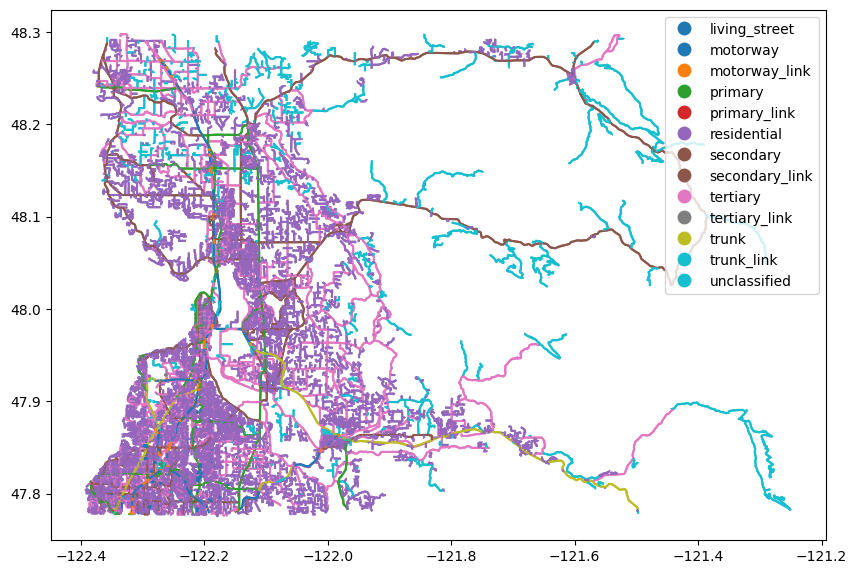

In [ ]:
gdf_edges.plot(column='highway', figsize=(10, 10), legend=True)

In [ ]:
default_speed = {
    'motorway': '60', 'motorway_link': '45', 'trunk': '55', 'trunk_link': '40',
    'primary': '45', 'primary_link': '40', 'secondary': '35', 'secondary_link': '30',
    'tertiary': '30', 'tertiary_link': '25', 'residential': '25', 'unclassified': '25', 'living_street': '10'
}

# Clean and convert maxspeed

# 1. Handle cases where 'highway' or 'maxspeed' is a list
gdf_edges['highway'] = gdf_edges['highway'].apply(lambda x: x[0] if isinstance(x, list) else x)
gdf_edges['maxspeed'] = gdf_edges['maxspeed'].apply(lambda x: x[0] if isinstance(x, list) else x)

# 2. Force to string, strip ALL letters (mph, km/h), and convert to float
# pd.to_numeric with coerce safely turns empty strings into clean NaNs for the math
gdf_edges['maxspeed'] = gdf_edges['maxspeed'].astype(str).str.replace(r'\D+', '', regex=True)
gdf_edges['maxspeed'] = pd.to_numeric(gdf_edges['maxspeed'], errors='coerce')

# 3. Map your default dictionary (and ensure it applies them as floats)
gdf_edges['maxspeed'] = gdf_edges['maxspeed'].fillna(gdf_edges['highway'].map(default_speed).astype(float))

# 4. Fill any remaining weird OSM road types (like 'alley' or 'service') with 25
gdf_edges['maxspeed'] = gdf_edges['maxspeed'].fillna(25)

# 5. Now that 100% of the NaNs are gone, it is completely safe to convert to integer!
gdf_edges['maxspeed'] = gdf_edges['maxspeed'].astype(int)

In [ ]:
gdf_edges['maxspeed'].isnull().sum()


np.int64(0)

In [ ]:
import shapely as shp
import math
help(math.atan2)

Help on built-in function atan2 in module math:

atan2(y, x, /)
    Return the arc tangent (measured in radians) of y/x.

    Unlike atan(y/x), the signs of both x and y are considered.



In [ ]:
from shapely import LineString


def compute_curvature(LineString):

    x, y = LineString.coords.xy
    currX = None
    currY = None
    bearing = 0
    prevbearing = None
    currbearing = None
    for n in range(len(x)):
        if n == 0:
            currX = x[n]
            currY = y[n]
        elif prevbearing is None:
            nextX = x[n]
            nextY = y[n]
            prevbearing = math.atan2(nextY - currY, nextX - currX)
            currX = nextX
            currY = nextY
        else:
            nextX = x[n]
            nextY = y[n]
            currbearing = math.atan2(nextY - currY, nextX - currX)
            diffBearing = abs(currbearing - prevbearing)
            diffBearing = min(diffBearing, math.pi)
            bearing = diffBearing - (math.pi*2) + bearing if diffBearing > math.pi else diffBearing + bearing
            prevbearing = currbearing
            currX = nextX
            currY = nextY

    return bearing
test_geom = gdf_edges['geometry'].iloc[0]
print(test_geom)
compute_curvature(test_geom)
for x in gdf_edges['geometry']:
    print(compute_curvature(x))
        

LINESTRING (-122.180471 47.7800028, -122.1804087 47.7800022, -122.1794657 47.7799935, -122.1790821 47.7799893)
0.0021277622856812877
0.00031028459469295555
0.0028499282824752115
0
0.0009089067597993772
0.002127762285681012
0
0.0003102845946931776
6.097735915311375e-05
0.0007004791424016776
0.002849928282475423
3.0063403940960853e-05
0.02722610732619013
1.8195699515625279
0.3849263725291603
1.0100983864431692
1.8195699515625277
0.00020961173230377855
0.4699867820364081
0.3849263725291605
0.0004511937745346195
3.006340394121629e-05
7.196667052472835
0.00020961173230382713
1.2901638686125305
0.9197373912884768
0.46998678203640853
4.26876473792013
0
7.2962441548345485
0.06402978187519381
0.9197373912884778
0
1.955898472189075
0.7541245762055391
1.5992302985471247
0.9836487340912508
7.691882039020613
1.9558984721890746
0.34289786196836625
0.06402978187519359
5.374893252209114
0.45378399831148397
0.3428978619683658
0
2.586797717101383
0.07639524816687393
0.0072199420758818356
0.2214453630339

In [ ]:
gdf_edges['curvature'] = gdf_edges['geometry'].apply(compute_curvature)
gdf_edges['curvature'].idxmax()

(np.int64(50608259), np.int64(50729315), np.int64(0))

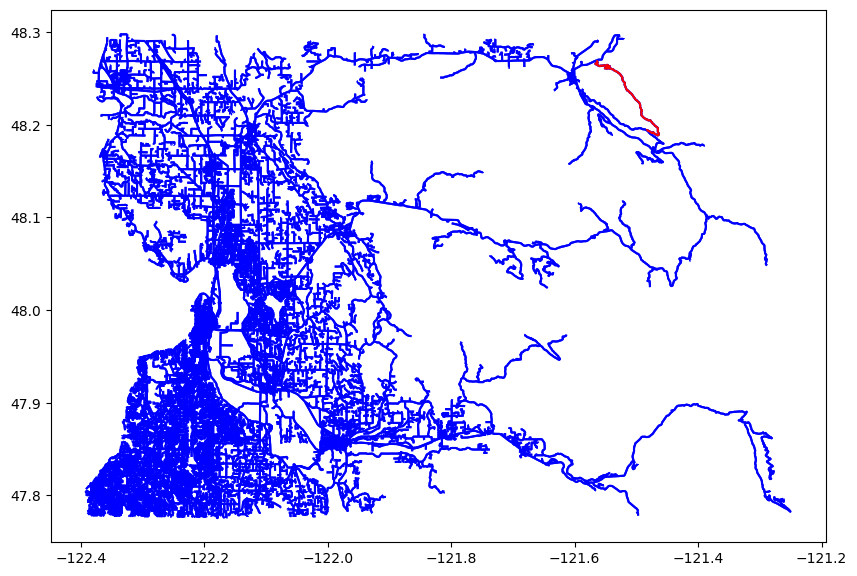

In [ ]:
import matplotlib.pyplot as plt
max_curve =gdf_edges[gdf_edges['curvature'] == gdf_edges['curvature'].max()]
fig, ax = plt.subplots(figsize=(10, 10))
gdf_edges.plot(ax =ax, color='blue', legend=True)
max_curve.plot(ax=ax, color='red', label='Max Curvature')
plt.show()




<Axes: >

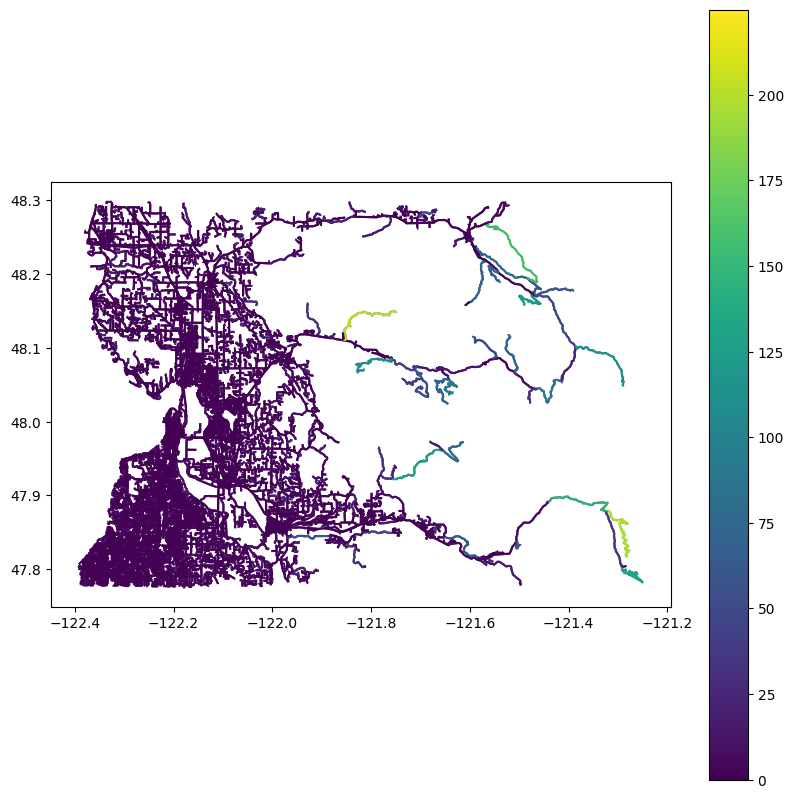

In [ ]:
gdf_edges.plot(column='curvature', figsize=(10, 10), legend=True)

In [ ]:
gdf_nodes.head()

,y,x,highway,street_count,elevation,ref,junction,railway,geometry
osmid,,,,,,,,,
30139417,47.780003,-122.180471,stop,3,26.0,NaN,NaN,NaN,POINT (-122.18047 47.78)
2304044269,47.779989,-122.179082,NaN,3,44.0,NaN,NaN,NaN,POINT (-122.17908 47.77999)
1194807327,47.779267,-122.180438,NaN,3,30.0,NaN,NaN,NaN,POINT (-122.18044 47.77927)
136904439,47.780062,-122.185885,stop,4,14.0,NaN,NaN,NaN,POINT (-122.18588 47.78006)
30139423,47.781047,-122.192030,NaN,3,26.0,NaN,NaN,NaN,POINT (-122.19203 47.78105)


In [ ]:
gdf_edges.head()

osmid      highway  \
u          v          key                                        
30139417   2304044269 0                 314941994     tertiary   
           1194807327 0    [428033729, 428033727]    secondary   
           136904439  0                 933078655     tertiary   
2304044269 2304044903 0                 314941994     tertiary   
           1194807334 0                 221378242  residential   

                                    maxspeed                    name  oneway  \
u          v          key                                                      
30139417   2304044269 0    43775433717285408  240th Street Southeast   False   
           1194807327 0     5032678828257017   39th Avenue Southeast   False   
           136904439  0    43775433717285408  240th Street Southeast   False   
2304044269 2304044903 0    43775433717285408  240th Street Southeast   False   
           1194807334 0     3657158199959149   40th Avenue Southeast   False   

                          reversed      length  \
u          v          key                        
30139417   2304044269 0      False  103.790617   
           1194807327 0       True   81.877399   
           136904439  0       True  404.590873   
2304044269 2304044903 0      False   40.111093   
           1194807334 0      False   81.825076   

                                                                    geometry  \
u          v          key                                                      
30139417   2304044269 0    LINESTRING (-122.18047 47.78, -122.18041 47.78...   
           1194807327 0    LINESTRING (-122.18047 47.78, -122.18047 47.77...   
           136904439  0    LINESTRING (-122.18047 47.78, -122.18101 47.78...   
2304044269 2304044903 0    LINESTRING (-122.17908 47.77999, -122.17855 47...   
           1194807334 0    LINESTRING (-122.17908 47.77999, -122.17908 47...   

                              grade  grade_abs  curvature  \
u          v          key                                   
30139417   2304044269 0    0.173426   0.173426   0.002128   
           1194807327 0    0.048854   0.048854   0.000310   
           136904439  0   -0.029660   0.029660   0.002850   
2304044269 2304044903 0    0.149585   0.149585   0.000000   
           1194807334 0    0.061106   0.061106   0.000909   

                           highway_effectiveness   lanes bridge  ref tunnel  \
u          v          key                                                     
30139417   2304044269 0                     0.95     NaN    NaN  NaN    NaN   
           1194807327 0                     0.90  [4, 5]    NaN  NaN    NaN   
           136904439  0                     0.95     NaN    NaN  NaN    NaN   
2304044269 2304044903 0                     0.95     NaN    NaN  NaN    NaN   
           1194807334 0                     0.40     NaN    NaN  NaN    NaN   

                          junction access width area  
u          v          key                             
30139417   2304044269 0        NaN    NaN   NaN  NaN  
           1194807327 0        NaN    NaN   NaN  NaN  
           136904439  0        NaN    NaN   NaN  NaN  
2304044269 2304044903 0        NaN    NaN   NaN  NaN  
           1194807334 0        NaN    NaN   NaN  NaN

In [ ]:
import pandas as pd
df_edges_matrix = gdf_edges[['length', 'maxspeed', 'grade','grade_abs', 'curvature','highway']]
df_highway_dummies = pd.get_dummies(df_edges_matrix['highway'], prefix='highway', drop_first =True)
df_edges_matrix.drop('highway', axis=1, inplace=True)
df_edges_matrix = pd.concat([df_edges_matrix, df_highway_dummies], axis=1)
print(df_edges_matrix.shape)
print(df_edges_matrix.isnull().sum())


(71455, 17)
length                    0
maxspeed                  0
grade                     0
grade_abs                 0
curvature                 0
highway_motorway          0
highway_motorway_link     0
highway_primary           0
highway_primary_link      0
highway_residential       0
highway_secondary         0
highway_secondary_link    0
highway_tertiary          0
highway_tertiary_link     0
highway_trunk             0
highway_trunk_link        0
highway_unclassified      0
dtype: int64


In [ ]:
for u, v, d in G.edges(data=True):
      print(u, v, d)
      break

30139417 2304044269 {'osmid': 314941994, 'highway': 'tertiary', 'maxspeed': 0.43775433717285417, 'name': '240th Street Southeast', 'oneway': False, 'reversed': False, 'length': 103.79061701550403, 'geometry': <LINESTRING (-122.18 47.78, -122.18 47.78, -122.179 47.78, -122.179 47.78)>, 'grade': np.float64(0.17342608144733543), 'grade_abs': np.float64(0.17342608144733543), 'curvature': 0.0003921437934321484, 'highway_effectiveness': 0.95}


In [ ]:
for u, v, d in G.edges(data=True):
      print(list(d.keys()))
      break

['osmid', 'highway', 'maxspeed', 'name', 'oneway', 'reversed', 'length', 'geometry', 'grade', 'grade_abs', 'curvature', 'highway_effectiveness']


In [ ]:
G = ox.graph_from_gdfs(gdf_nodes, gdf_edges)
for u, v, d in G.edges(data=True):
      print(list(d.keys()))
      break

['osmid', 'highway', 'maxspeed', 'name', 'oneway', 'reversed', 'length', 'geometry', 'grade', 'grade_abs', 'curvature', 'highway_effectiveness']


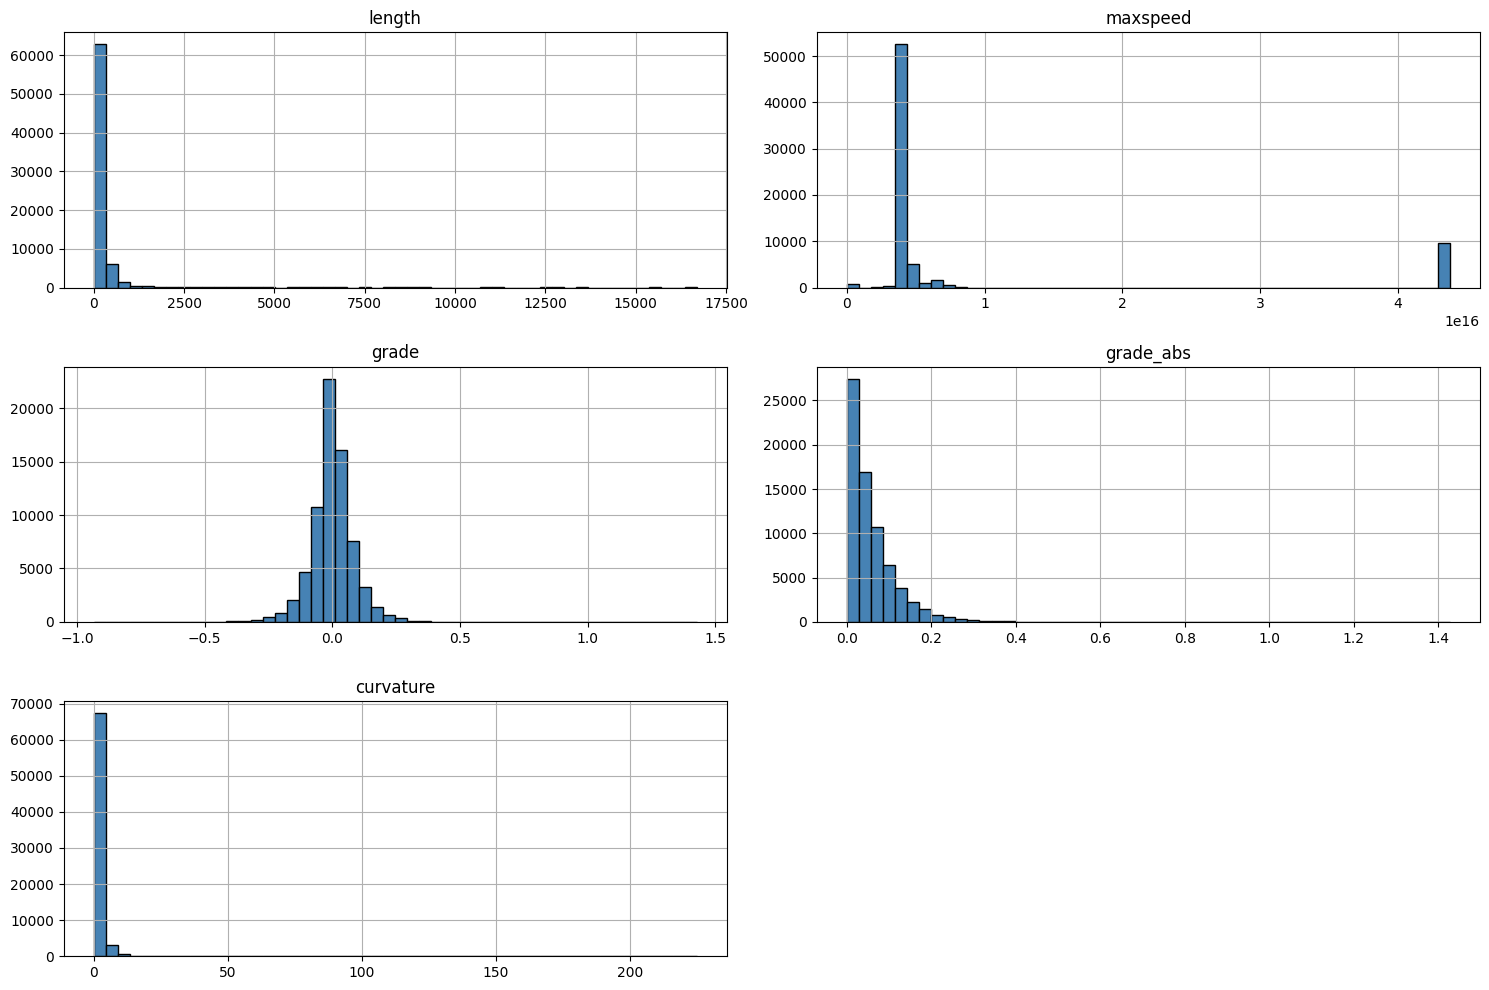

In [ ]:
df_edges_matrix.hist(
    figsize=(15, 10), 
    bins=50, 
    color='steelblue', 
    edgecolor='black'
)

# This prevents the subplot titles from overlapping
plt.tight_layout() 

plt.show()

<Axes: >

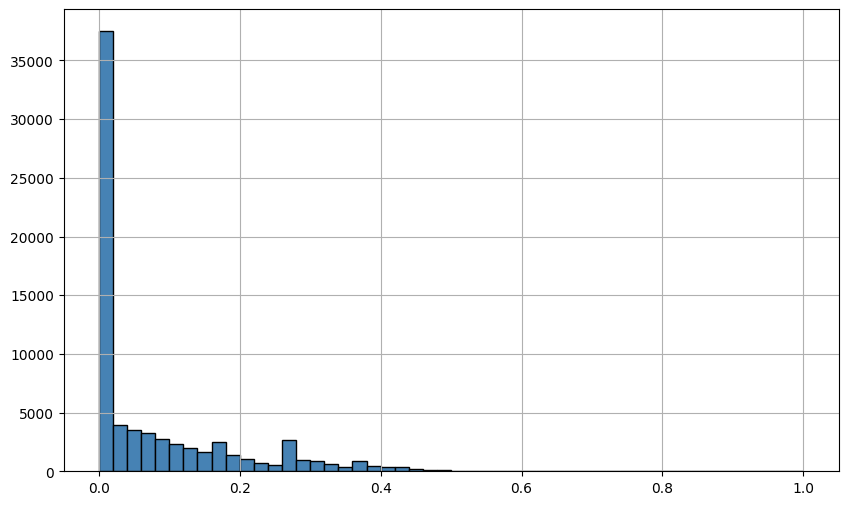

In [ ]:
import numpy as np
normalized_gdf_edges = gdf_edges.copy()
normalized_gdf_edges['curvature'] = np.log1p(normalized_gdf_edges['curvature'])
n_min = normalized_gdf_edges['curvature'].min()
n_max = normalized_gdf_edges['curvature'].max()
normalized_gdf_edges['curvature'] = (normalized_gdf_edges['curvature'] - n_min) / (n_max - n_min)
normalized_gdf_edges['curvature'].hist(
    figsize=(10, 6), 
    bins=50, 
    color='steelblue', 
    edgecolor='black'
)

43775433717285408


<Axes: >

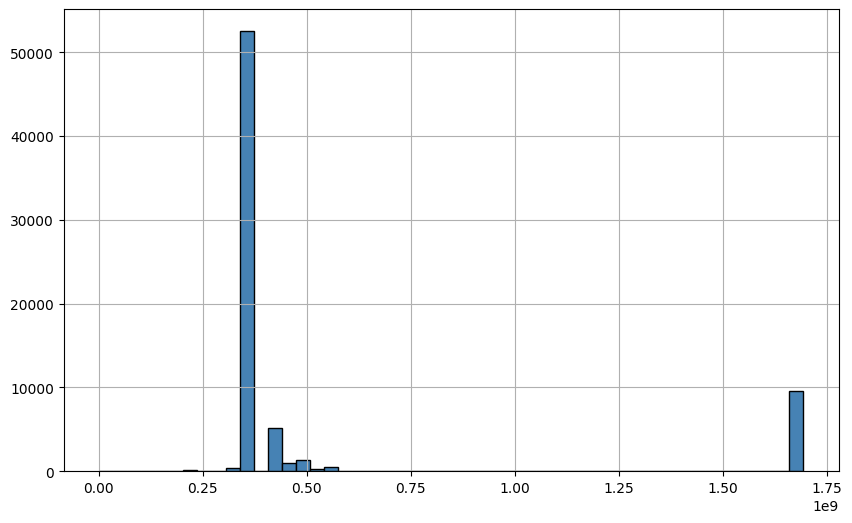

In [ ]:
# 10 is a minimum speed limit and 85 is a maximum speed limit
#0.625 gives an exponential distribution with 35mp being the center
print(normalized_gdf_edges['maxspeed'].max())
normalized_gdf_edges['maxspeed'] = ((normalized_gdf_edges['maxspeed'] - 10) / (85 - 10) )** 0.625 
normalized_gdf_edges['maxspeed'].hist(
    figsize=(10, 6), 
    bins=50, 
    color='steelblue', 
    edgecolor='black'
)

<Axes: >

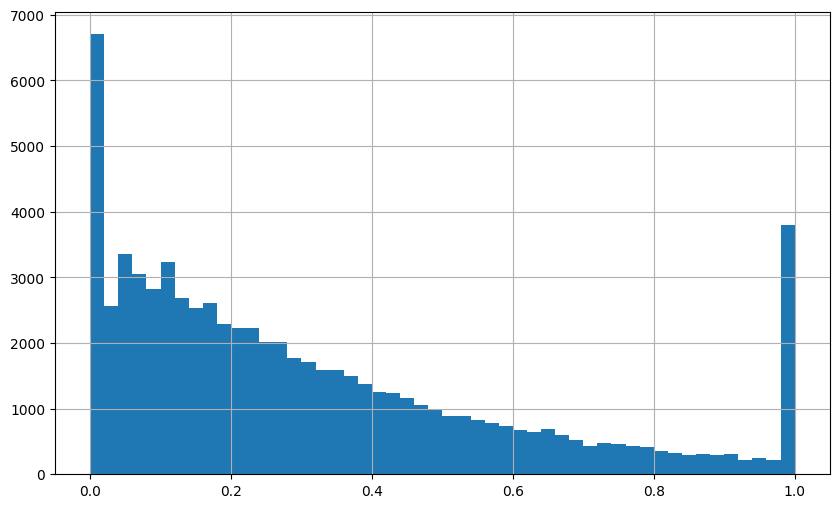

In [ ]:
lower_bounds = normalized_gdf_edges['grade_abs'].quantile(0.05)
higher_bounds = normalized_gdf_edges['grade_abs'].quantile(0.95)

normalized_gdf_edges['grade_abs'] = normalized_gdf_edges['grade_abs'].clip(lower=lower_bounds, upper=higher_bounds)
min_grade = normalized_gdf_edges['grade_abs'].min()
max_grade = normalized_gdf_edges['grade_abs'].max()
normalized_gdf_edges['grade_abs'] = (normalized_gdf_edges['grade_abs'] - min_grade) / (max_grade - min_grade)
normalized_gdf_edges['grade_abs'].hist(
    figsize=(10, 6),
    bins=50
)

<Axes: >

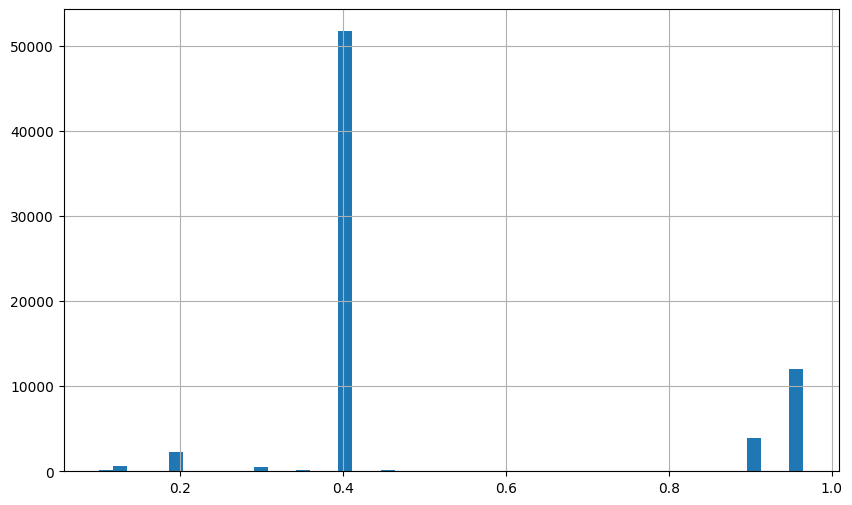

In [ ]:
highway_effectiveness = {
    # INTERSTATES & FREEWAYS: The highest capacity roads. Completely divided, no intersections.
    # Score: -0.6 (Severely penalized. Long, straight, boring, and full of semi-trucks.)
    'motorway': 0.1,       
    
    # ON/OFF RAMPS: The slip roads leading onto or off of a motorway.
    # Score: 0.2 (Sometimes a fun 270-degree sweeper, but too short to be the goal of a ride.)
    'motorway_link': 0.2,
    
    # MAJOR HIGHWAYS: Important divided roads, but slightly a step down from a full Interstate.
    # Score: 0.3 (High speed, but usually straight and heavily policed.)
    'trunk': 0.3,          
    
    # ON/OFF RAMPS for trunk roads.
    'trunk_link': 0.35,
    
    # ARTERIAL ROADS: Major roads linking large towns and cities together.
    # Score: 0.4 (Can be scenic, but usually have high traffic volume and stoplights.)
    'primary': 0.4,        
    
    # CONNECTORS for primary roads.
    'primary_link': 0.45,
    
    # REGIONAL ROADS: Medium-capacity roads linking smaller towns and villages.
    # Score: 0.9 (Great balance. Fast enough to be fun, rural enough to have sweeping curves, lower traffic.)
    'secondary': 0.9,      
    
    # CONNECTORS for secondary roads.
    'secondary_link': 0.85,
    
    # LOCAL CONNECTOR ROADS: Roads connecting smaller settlements or local districts.
    # Score: 0.8 (The "Sweet Spot" for twists. Often follow natural topography like rivers and hills.)
    'tertiary': 0.95,       
    
    # CONNECTORS for tertiary roads.
    'tertiary_link': 0.965,
    
    # NEIGHBORHOOD STREETS: Roads lined with houses and driveways.
    # Score: 0.4 (Lots of turns, but very low speed limits, stop signs, and kids playing.)
    'residential': 0.4,    
    
    # RURAL/MINOR ROADS: The lowest level of connecting road. Despite the name, it just means "local road".
    # Score: 0.55 (A gamble. Can be an amazing hidden canyon twisty, or a bumpy dirt road.)
    'unclassified': 0.2,  
    
    # PEDESTRIAN PRIORITY ZONES: Shared-space streets where pedestrians have the legal right of way.
    # Score: 0.12 (Extremely slow speed limits, actively avoiding these is a priority.)
    'living_street': 0.12  
}
normalized_gdf_edges['highway_effectiveness'] = normalized_gdf_edges['highway'].map(highway_effectiveness).fillna(0.5)
normalized_gdf_edges['highway_effectiveness'].hist(
    figsize=(10, 6),
    bins=50
)

In [ ]:
G = ox.graph_from_gdfs(gdf_nodes, normalized_gdf_edges)
for u, v, d in G.edges(data=True):
      print(list(d.keys()))
      break
normalized_gdf_edges.head()

['osmid', 'highway', 'maxspeed', 'name', 'oneway', 'reversed', 'length', 'geometry', 'grade', 'grade_abs', 'curvature', 'highway_effectiveness']


osmid      highway      maxspeed  \
u          v          key                                                      
30139417   2304044269 0                 314941994     tertiary  1.693775e+09   
           1194807327 0    [428033729, 428033727]    secondary  4.382392e+08   
           136904439  0                 933078655     tertiary  1.693775e+09   
2304044269 2304044903 0                 314941994     tertiary  1.693775e+09   
           1194807334 0                 221378242  residential  3.589645e+08   

                                             name  oneway reversed  \
u          v          key                                            
30139417   2304044269 0    240th Street Southeast   False    False   
           1194807327 0     39th Avenue Southeast   False     True   
           136904439  0    240th Street Southeast   False     True   
2304044269 2304044903 0    240th Street Southeast   False    False   
           1194807334 0     40th Avenue Southeast   False    False   

                               length  \
u          v          key               
30139417   2304044269 0    103.790617   
           1194807327 0     81.877399   
           136904439  0    404.590873   
2304044269 2304044903 0     40.111093   
           1194807334 0     81.825076   

                                                                    geometry  \
u          v          key                                                      
30139417   2304044269 0    LINESTRING (-122.18047 47.78, -122.18041 47.78...   
           1194807327 0    LINESTRING (-122.18047 47.78, -122.18047 47.77...   
           136904439  0    LINESTRING (-122.18047 47.78, -122.18101 47.78...   
2304044269 2304044903 0    LINESTRING (-122.17908 47.77999, -122.17855 47...   
           1194807334 0    LINESTRING (-122.17908 47.77999, -122.17908 47...   

                              grade  grade_abs  curvature  \
u          v          key                                   
30139417   2304044269 0    0.173426   0.991929   0.000392   
           1194807327 0    0.048854   0.279423   0.000057   
           136904439  0   -0.029660   0.169641   0.000525   
2304044269 2304044903 0    0.149585   0.855565   0.000000   
           1194807334 0    0.061106   0.349502   0.000168   

                           highway_effectiveness   lanes bridge  ref tunnel  \
u          v          key                                                     
30139417   2304044269 0                     0.95     NaN    NaN  NaN    NaN   
           1194807327 0                     0.90  [4, 5]    NaN  NaN    NaN   
           136904439  0                     0.95     NaN    NaN  NaN    NaN   
2304044269 2304044903 0                     0.95     NaN    NaN  NaN    NaN   
           1194807334 0                     0.40     NaN    NaN  NaN    NaN   

                          junction access width area  
u          v          key                             
30139417   2304044269 0        NaN    NaN   NaN  NaN  
           1194807327 0        NaN    NaN   NaN  NaN  
           136904439  0        NaN    NaN   NaN  NaN  
2304044269 2304044903 0        NaN    NaN   NaN  NaN  
           1194807334 0        NaN    NaN   NaN  NaN

In [ ]:

# Handle MultiDiGraph structure (dictionary of dictionaries)
def fun_score(u, v, d):
    # Handle MultiDiGraph structure (dictionary of dictionaries)
    if 0 in d:
        d = d[0]

    # Use .get(key, default) to safely handle missing data
    maxspeed = d.get('maxspeed', d.get('maxspeed', 0))
    grade = d.get('grade_abs_norm', d.get('grade_abs', 0))
    curvature = d.get('curvature', 0)
    penalty = d.get('highway_effectiveness', 1.0)

    score = (maxspeed * 0.1) + (grade * 0.1) + (curvature * 0.6) + (penalty * 0.2)

    # Ensure score doesn't exceed 1.0
    score = min(score, 1.0)

    return (1 - score) * d['length']
   
    

In [ ]:
import networkx as nx
u, v, key = gdf_edges.index[0]
nx.dijkstra_path(G, u, v, weight=fun_score)

[np.int64(30139417), np.int64(2304044269)]

In [ ]:
G.nodes[u]

{'y': 47.7800028,
 'x': -122.180471,
 'highway': 'stop',
 'street_count': 3,
 'elevation': 26.0}

In [ ]:
for u, v, d in G.edges(data=True):
      print(list(d.keys()))
      break
print(normalized_gdf_edges['curvature'].isnull().sum())
print(gdf_edges['curvature'].isnull().sum())
if normalized_gdf_edges['curvature'].isnull:
    print(normalized_gdf_edges['geometry'])
print(gdf_edges['curvature'].min())

['osmid', 'highway', 'maxspeed', 'name', 'oneway', 'reversed', 'length', 'geometry', 'grade', 'grade_abs', 'curvature', 'highway_effectiveness']
0
0
u           v           key
30139417    2304044269  0      LINESTRING (-122.18047 47.78, -122.18041 47.78...
            1194807327  0      LINESTRING (-122.18047 47.78, -122.18047 47.77...
            136904439   0      LINESTRING (-122.18047 47.78, -122.18101 47.78...
2304044269  2304044903  0      LINESTRING (-122.17908 47.77999, -122.17855 47...
            1194807334  0      LINESTRING (-122.17908 47.77999, -122.17908 47...
                                                     ...                        
50652617    50652615    0      LINESTRING (-121.29229 47.80307, -121.29249 47...
            5767502023  0      LINESTRING (-121.29229 47.80307, -121.29203 47...
            783648724   0      LINESTRING (-121.29229 47.80307, -121.29085 47...
5767502023  50652617    0      LINESTRING (-121.26237 47.79663, -121.26242 47...
783648724   5

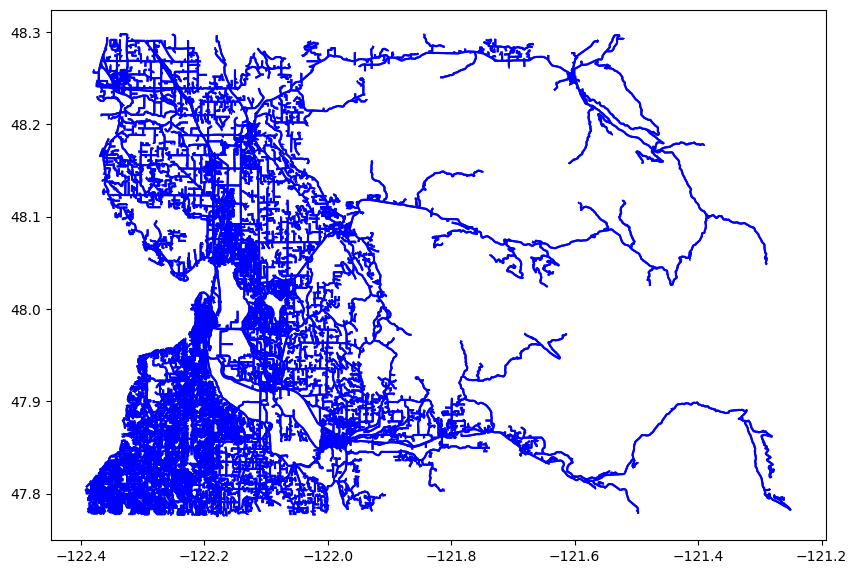

In [ ]:
null_curve = normalized_gdf_edges[normalized_gdf_edges['curvature'].isnull()]
fig, ax = plt.subplots(figsize=(10, 10))
normalized_gdf_edges.plot(ax=ax, color='blue', legend=True)

if not null_curve.empty:
	null_curve.plot(ax=ax, color='red', label='Null Curvature')

plt.show()

In [ ]:
distance, path = nx.single_source_dijkstra(G, u, cutoff= 100000, weight="length")
filter_distance_dict = {k: v for k, v in distance.items() if v >= 50000 and v < 100000}
print(filter_distance_dict)
len(filter_distance_dict)

{434869048: 50004.305601591164, 434864188: 50015.46508649354, 6972381993: 50025.10652958009, 50719146: 50042.37380667033, 50680528: 50042.44559176369, 5359205510: 50047.861935296925, 434870730: 50051.31381918296, 50813292: 50052.44839725737, 434938673: 50053.75713050018, 434868424: 50057.51940489445, 434940731: 50063.91647329772, 50610335: 50064.8137043534, 434900809: 50068.95245259243, 5412634003: 50074.623464824515, 6117373960: 50074.71509711138, 7331947459: 50077.53981635467, 50784051: 50077.640152918815, 50622318: 50079.19335716783, 6117450720: 50080.95278928253, 50679675: 50092.605322524585, 50688964: 50093.065399650826, 6888074401: 50093.51020577106, 50624526: 50095.80236554645, 5359205511: 50097.06651463148, 50774486: 50107.108225086944, 50700394: 50107.313687059366, 6117374209: 50112.4115303314, 50674091: 50114.6274688227, 434870755: 50120.732842537196, 50662522: 50122.02758478537, 50670154: 50130.879646266476, 3056811851: 50132.21940454384, 434868667: 50133.287891743064, 43489

2671

In [ ]:
nx.single_source_dijkstra(G, u, cutoff= 100000, weight="length")
distance_fun, path_fun = nx.single_source_dijkstra(G, u, weight=fun_score) 
dest = min(filter_distance_dict, key=lambda n: distance_fun[n]) 
print(path_fun[dest])

[30139417, 136904439, 136903837, 30139423, 30139428, 30139431, 30139437, 286303710, 30139439, 50710760, 50739889, 4677213178, 5041319726, 50707517, 50684448, 50723331, 50723336, 10111155304, 136966103, 10111155300, 30757967, 30757994, 136955727, 2951834523, 13318766189, 30360425, 30360713, 50689309, 412351963, 1851238945, 1851238917, 1851238946, 296004429, 296006192, 296006474, 1036479963, 50786985, 1880987759, 50646153, 316832262, 2670856973, 297111367, 316868945, 316869155, 50788385, 50788400, 317428024, 356203035, 50803420, 50803398, 50803888, 50803909, 317497841, 317497818, 50804234, 50804226, 3768376210, 50651876, 50795836, 434846170, 50639347, 434939426, 50665533, 50665538, 434938175, 50665553, 50665558, 50665562, 4741926499, 50665601, 50744954, 50700394, 434869048]


In [ ]:
print(path_fun[dest])

[30139417, 136904439, 136903837, 30139423, 30139428, 30139431, 30139437, 286303710, 30139439, 50710760, 50739889, 4677213178, 5041319726, 50707517, 50684448, 50723331, 50723336, 10111155304, 136966103, 10111155300, 30757967, 30757994, 136955727, 2951834523, 13318766189, 30360425, 30360713, 50689309, 412351963, 1851238945, 1851238917, 1851238946, 296004429, 296006192, 296006474, 1036479963, 50786985, 1880987759, 50646153, 316832262, 2670856973, 297111367, 316868945, 316869155, 50788385, 50788400, 317428024, 356203035, 50803420, 50803398, 50803888, 50803909, 317497841, 317497818, 50804234, 50804226, 3768376210, 50651876, 50795836, 434846170, 50639347, 434939426, 50665533, 50665538, 434938175, 50665553, 50665558, 50665562, 4741926499, 50665601, 50744954, 50700394, 434869048]


In [ ]:
return_path = nx.dijkstra_path(G,dest, u, weight=fun_score)
print(return_path)

[434869048, 50700394, 50744954, 50665601, 4741926499, 50665562, 50665558, 50665553, 434938175, 50665538, 50665533, 434939426, 50639347, 434846170, 50795836, 50651876, 3768376210, 50804226, 50604808, 50689773, 1727092268, 356203039, 50689745, 50803941, 317432307, 50803390, 50689693, 50689686, 50788366, 50788383, 356203097, 316868943, 2635582429, 316832531, 50689579, 2270959128, 50689553, 527335917, 50689541, 281355018, 296001664, 4755193806, 436946354, 1388978704, 444215021, 1388978589, 50689474, 50689469, 50689452, 1802209690, 30361049, 1380011549, 30361091, 13316222164, 4041063053, 136950297, 50812518, 31031942, 136963223, 136955733, 31193651, 30757967, 10111155300, 10111155304, 50723336, 50723331, 50684448, 50707517, 5041319726, 4677213178, 50739889, 50710760, 30139439, 286303710, 30139437, 30139431, 30139428, 30139423, 136903837, 136904439, 30139417]


In [ ]:
round_trip = path_fun[dest] + return_path[1:]
print(round_trip)

[30139417, 136904439, 136903837, 30139423, 30139428, 30139431, 30139437, 286303710, 30139439, 50710760, 50739889, 4677213178, 5041319726, 50707517, 50684448, 50723331, 50723336, 10111155304, 136966103, 10111155300, 30757967, 30757994, 136955727, 2951834523, 13318766189, 30360425, 30360713, 50689309, 412351963, 1851238945, 1851238917, 1851238946, 296004429, 296006192, 296006474, 1036479963, 50786985, 1880987759, 50646153, 316832262, 2670856973, 297111367, 316868945, 316869155, 50788385, 50788400, 317428024, 356203035, 50803420, 50803398, 50803888, 50803909, 317497841, 317497818, 50804234, 50804226, 3768376210, 50651876, 50795836, 434846170, 50639347, 434939426, 50665533, 50665538, 434938175, 50665553, 50665558, 50665562, 4741926499, 50665601, 50744954, 50700394, 434869048, 50700394, 50744954, 50665601, 4741926499, 50665562, 50665558, 50665553, 434938175, 50665538, 50665533, 434939426, 50639347, 434846170, 50795836, 50651876, 3768376210, 50804226, 50604808, 50689773, 1727092268, 35620303

In [ ]:
# .loc[row_label, column_label]
lat = gdf_nodes.loc[round_trip, 'y'].values
lon = gdf_nodes.loc[round_trip, 'x'].values
lat_lon = list(zip(lat, lon)) 
print(lat_lon)


[(np.float64(47.7800028), np.float64(-122.180471)), (np.float64(47.7800616), np.float64(-122.185885)), (np.float64(47.780065), np.float64(-122.1873508)), (np.float64(47.7810472), np.float64(-122.1920302)), (np.float64(47.7837789), np.float64(-122.1941625)), (np.float64(47.7860481), np.float64(-122.195738)), (np.float64(47.788039), np.float64(-122.1970715)), (np.float64(47.7902082), np.float64(-122.1972093)), (np.float64(47.790655), np.float64(-122.1973273)), (np.float64(47.7912538), np.float64(-122.1976499)), (np.float64(47.79128), np.float64(-122.196036)), (np.float64(47.7931807), np.float64(-122.1959304)), (np.float64(47.7957245), np.float64(-122.1969923)), (np.float64(47.7993027), np.float64(-122.1987057)), (np.float64(47.7993361), np.float64(-122.2019612)), (np.float64(47.7991622), np.float64(-122.2060638)), (np.float64(47.7982465), np.float64(-122.2107152)), (np.float64(47.7983556), np.float64(-122.2113682)), (np.float64(47.7985457), np.float64(-122.2120286)), (np.float64(47.79813

In [ ]:
import folium
m = folium.Map(location=[47.9334204, -122.0823321], zoom_start=11)
folium.PolyLine(lat_lon, tooltip="Road").add_to(m)
m.save('round_trip_map.html')